In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

armsData = pd.read_csv('../data/cow_arms_tech_long.csv')
nationalMaterialCapabilities = pd.read_csv('../data/NMC-70-abridged.csv') 
countryCodes = pd.read_csv('../data/COW-country-codes.csv')

armsData.head()
nationalMaterialCapabilities.head()
countryCodes.head()

armsData.info()
nationalMaterialCapabilities.info()
countryCodes.info()


<class 'pandas.DataFrame'>
RangeIndex: 522272 entries, 0 to 522271
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ccode      522272 non-null  int64  
 1   stateabb   522272 non-null  str    
 2   statename  522272 non-null  str    
 3   techname   522272 non-null  str    
 4   techtype   522272 non-null  str    
 5   year       522272 non-null  int64  
 6   use        504148 non-null  float64
 7   total_use  15187 non-null   float64
 8   version    522272 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 35.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 17121 entries, 0 to 17120
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   stateabb  17121 non-null  str    
 1   ccode     17121 non-null  int64  
 2   year      17121 non-null  int64  
 3   milex     17121 non-null  int64  
 4   milper    17121 non-null  int64  
 5   irst      17121

Considering the size of these data sets (within the single or double digits of megabytes) and their nature as compiled historical datasets (i.e. with very little velocity) an automated data collection system is unecessary.

First, common categories.
ccode and stateabb are numerical and 3 character string country identifiers respectively, the numerical key will be how the datasets are merged.

The first of these outputs is a summary of the large, long format arms dataset with each row representing an instance of a country adopting one of 31 arms technologies in a given year, the 'use' category has 4 states, 0 meaning not used in current or previous years, 1 meaning used in current year and in any year prior to the current year and hasnt yet been superseded, 9 meaning that a technology was superseded but was once used, and N/A meaning missing data. Cases when states leap-frog a technology can be identified in the data by checking if use jumps from 0 to 9 without ever being coded as 1. the 'use' category is missing entries as a result of incomplete historical data, and 'total use' is a sort of aggregate value that represents the overall 'technology state' for a given country in a given year, so doesnt have as many entries but also doesnt include an entry if any one 'use' category from that country-year is missing. This means that a portion of data doesnt meet the criteria to have an associated 'total_use' figure, and that gap speaks to potential for analysis. Part of the mismatch between the number of 'use' entries and the numbers of total entries is because each instance of the use_total category has its own row, there is a portion of data that is simply missing but the difference isnt as extreme as the ~18,000 record disparity there. This data also excludes states with less than half a million inhabitants.

The second is the national material capabilities dataset which doesnt seem to have any missing entries as per this diagnostic but in reality represents null entries by interpolating trends or otherwise marking the entry with '0' depending on the evidence available for a given entry, which is difficult to meaningfully clean as '0' is a perfectly valid entry for many nations in many time periods. This data contains variables like total and urban populations, military personnel and expenditure counts, energy consumption and iron & steel production, all sorted by country and year, as well as CINC or 'Composite Index of National Capability' which sums each metric category across all states in a year for a global total, then the score of a each metric in each country is converted to a proportion of the global total of that metric and summed with the other proportions of that entry and averaged to produce a single CINC value.

The third is the country code index, which has been shown to be redundant as the index information is also contained within the arms data.

--- Missing data overview ---
Total missing values in 'use' column: 18124
Percentage of data missing: 3.47%

--- Missing values by techname ---
techname
Adopted technologies             16321
Percussion lock musket             247
Hand-cranked machine gun           215
Recoilless artillery               212
Assault Rifle                      168
Rifled artillery                   167
Automatic machine gun              163
Steel tube artillery               137
Minié Rifle                        120
Breechloading artillery            107
Box magazine rifle                  64
Tubular magazine rifle              43
WWII era tank (or equivalent)       39
Breechloading rifle                 37
WWII era figher                     33
Early tank                          31
Field gun                            8
Early warplane                       6
Flintlock musket                     6
Name: count, dtype: int64

--- Missing technology use entry by year ---
year
2011    172
2012    172
2013 

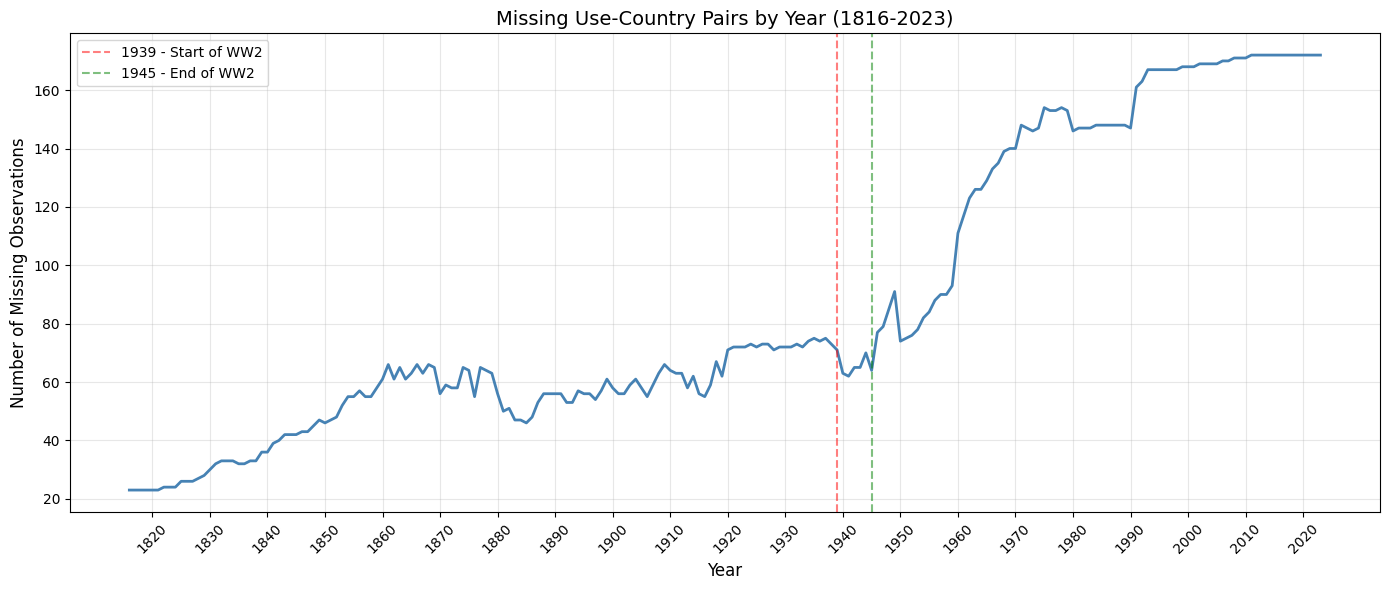

In [4]:

# Exploratory analysis of missing data.
print("--- Missing data overview ---")
totalMissing = armsData['use'].isnull().sum()
totalRows = len(armsData)
print(f"Total missing values in 'use' column: {totalMissing}")
print(f"Percentage of data missing: {totalMissing / totalRows * 100:.2f}%")

print("\n--- Missing values by techname ---")
missingByTechname = armsData[armsData['use'].isnull()]['techname'].value_counts()
print(missingByTechname)

print("\n--- Missing technology use entry by year ---")
missingByYear = armsData[armsData['use'].isnull()]['year'].value_counts()
print(missingByYear)

print("\n--- Missing technology use entry by country ---")
missingByCountry = armsData[armsData['use'].isnull()]['statename'].value_counts()
print(missingByCountry)

# Compares missing values in total_use rows against technology rows.
print("\n--- Summary ---")
summaryMissing = armsData[(armsData['techname'] == 'Adopted technologies') & (armsData['use'].isnull())]
techMissing = armsData[(armsData['techname'] != 'Adopted technologies') & (armsData['use'].isnull())]
print(f"Missing in total_use rows ('Adopted technologies'): {len(summaryMissing)}")
print(f"Missing in technology rows: {len(techMissing)}")
print(f"Total missing: {len(summaryMissing) + len(techMissing)}")

# Visualises missingness over time.
missingByYearAll = armsData[armsData['use'].isnull()]['year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(missingByYearAll.index, missingByYearAll.values, linewidth=2, color='steelblue')
plt.axvline(x=1939, color='red', linestyle='--', alpha=0.5, label='1939 - Start of WW2')
plt.axvline(x=1945, color='green', linestyle='--', alpha=0.5, label='1945 - End of WW2')
plt.title('Missing Use-Country Pairs by Year (1816-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Missing Observations', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
yearsToShow = list(range(1820, 2023, 10))
plt.xticks(yearsToShow, rotation=45)
plt.tight_layout()
plt.show()

Its clear there are some trends in what data is missing related to what data is historically available, the drop in missing entries from 1939 to 1940 could indicate countries being occupied and no data being available for them, for instance. Or the doubling of missing entries between 1945 and the mid 60s could indicate blind spots in data from the dozens of new states born from the decolonial trend of the post-ww2 years. The absense of this data speaks to some interesting geopolitical trends worth analysing. To this end records with missing data will have their own analytical category. Combining this dataset with the NMC data could also reveal some interesting insights, analysing the relationship between military industrial capacity and level of adopted technologies in regions with poor data may yield some insight. This will require aggregating the technology data to merge nicely with the NMC data as that data is at the country-year level, where the technology data is in a more decomposed form. maybe something like a 'technologiesAdopted' category to collate the number of adopted technologies per year, then containing those adopted technologies as an array associated with the year instead of having individual records per adoption. The total_use rows will also have to be filtered out, their peer-reviewed nature will make them useful for validating the entries with relevant tech-counts.

In [5]:

# Filters out total_use rows & verifies their absence.
print("--- Filtering total_use rows ---")
print(f"Rows before filtering: {len(armsData)}")
armsDataFiltered = armsData[armsData['techname'] != 'Adopted technologies']
print(f"Rows after filtering: {len(armsDataFiltered)}")
print(f"Rows removed: {len(armsData) - len(armsDataFiltered)}")
print(f"\ntotal_use rows remaining: {len(armsDataFiltered[armsDataFiltered['techname'] == 'Adopted technologies'])}")

# Technology adoption indicator.
def adoptionCode(x):
    if x in [1, 9]:
        return 'adopted'
    elif x == 0:
        return 'not_adopted'
    else:
        return 'missing'

armsDataFiltered['adoptionStatus'] = armsDataFiltered['use'].apply(adoptionCode)

# Checks the distribution of adoptionStatus.
print("\n--- Instances of technology adoption distribution ---")
print(armsDataFiltered['adoptionStatus'].value_counts(dropna=False))

# Aggregates to country-year level.
techAdoption = armsDataFiltered.groupby(['ccode', 'year'], as_index=False).agg(
    techCount=('adoptionStatus', lambda x: (x == 'adopted').sum()),
    techNotAdopted=('adoptionStatus', lambda x: (x == 'not_adopted').sum()),
    techMissing=('adoptionStatus', lambda x: (x == 'missing').sum())
)

# Creates lists of adopted technologies per country-year.
techList = armsDataFiltered[armsDataFiltered['adoptionStatus'] == 'adopted'].groupby(['ccode', 'year'])['techname'].agg(list).reset_index()
techList.rename(columns={'techname': 'adoptedTechList'}, inplace=True)
# Merges the lists into the dataset.
techAdoption = pd.merge(techAdoption, techList, on=['ccode', 'year'], how='left')

print("\n--- Data preview ---")
print(techAdoption[['ccode', 'year', 'techCount', 'techNotAdopted', 'techMissing', 'adoptedTechList']].head(10))


# Validation checks.
print(f"\n--- Validation checks ---")
print(f"\nTotal Country-years: {len(techAdoption)}")
print(f"Country-years with complete data: {(techAdoption['techMissing'] == 0).sum()}")
print(f"Country-years with missing data: {(techAdoption['techMissing'] > 0).sum()}")
# Extracts total_use where valid data exists.
totalUseData = armsData[armsData['techname'] == 'Adopted technologies'][['ccode', 'year', 'total_use']].drop_duplicates()
totalUseDataValid = totalUseData[totalUseData['total_use'].notna()]
# Merges with techAdoption to test the validity of techCount metric.
validationData = pd.merge(techAdoption, totalUseDataValid, on=['ccode', 'year'], how='inner')
print(f"\nCountry-years with valid total_use and techCount: {len(validationData)}")
# Checks for mismatches.
validationData['diff'] = validationData['techCount'] - validationData['total_use']
mismatches = validationData[validationData['diff'] != 0]
if len(mismatches) == 0:
    print("techCount matches total_use for all overlapping country-years")
else:
    print(f"Found {len(mismatches)} mismatches.")
    print(mismatches[['ccode', 'year', 'techCount', 'total_use', 'diff']].head(10))


--- Filtering total_use rows ---
Rows before filtering: 522272
Rows after filtering: 505951
Rows removed: 16321

total_use rows remaining: 0

--- Instances of technology adoption distribution ---
adoptionStatus
adopted        271396
not_adopted    232752
missing          1803
Name: count, dtype: int64

--- Data preview ---
   ccode  year  techCount  techNotAdopted  techMissing  \
0      2  1816          2              29            0   
1      2  1817          2              29            0   
2      2  1818          2              29            0   
3      2  1819          2              29            0   
4      2  1820          2              29            0   
5      2  1821          2              29            0   
6      2  1822          2              29            0   
7      2  1823          2              29            0   
8      2  1824          2              29            0   
9      2  1825          2              29            0   

                 adoptedTechList  
0

The NMC data contains countries not represented in the tech data as a result of its differing criteria of inclusion, however this data cant be trimmed as it contributes to the CINC index. These countries are just too small to have made it onto the weapons technology dataset but their industrial information is relevant so they'll have all their techcount/techmissing/techadopted values set to 0 rather than N/A to avoid processing errors, and the countrycode file will be integrated to provide them with full state names rather than just identifier codes.

In [ ]:

analysisData = nationalMaterialCapabilities.copy()
# Merges techAdoption.
analysisData = pd.merge(analysisData, techAdoption, on=['ccode', 'year'], how='left')

# Fills missing techAdoption values with 0 (accounting for merged NMC entries).
analysisData['techCount'] = analysisData['techCount'].fillna(0)
analysisData['techNotAdopted'] = analysisData['techNotAdopted'].fillna(0)
analysisData['techMissing'] = analysisData['techMissing'].fillna(0)

# Merges country codes (and solves a frustrating duplication problem
# that stemmed from the country codes merge).
countryCodes = pd.read_csv('../data/COW-country-codes.csv')
countryCodes.columns = ['stateabb', 'ccode', 'statename']
countryCodes = countryCodes.drop_duplicates(subset=['ccode'], keep='first')
analysisData = pd.merge(analysisData, countryCodes[['ccode', 'statename']], on='ccode', how='left')


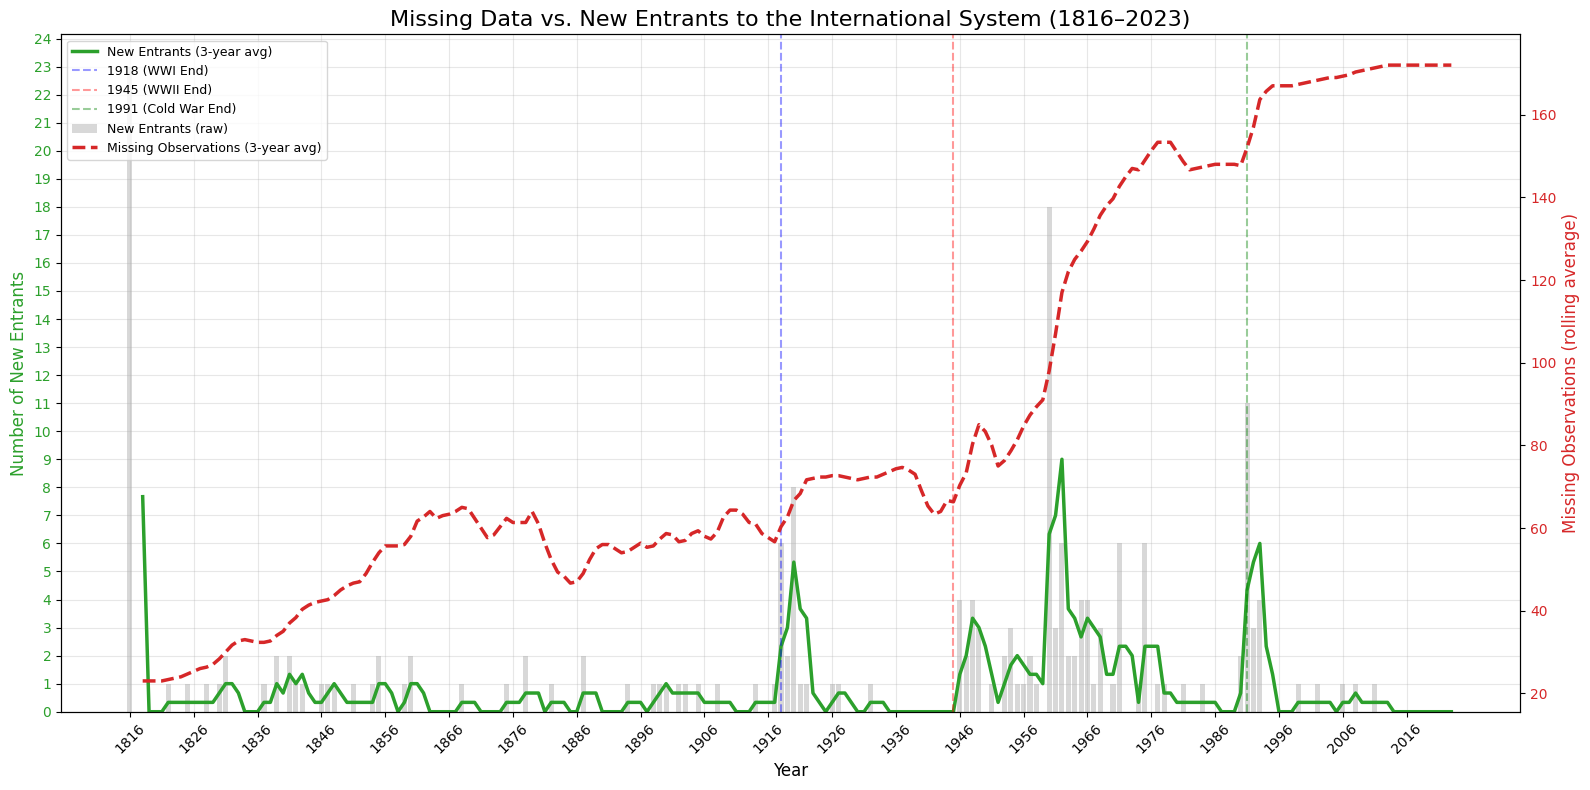

Pearson correlation: 0.0408
P-value: 0.5585
Lag 1: r = 0.0500, p = 0.4743
Lag 2: r = 0.0582, p = 0.4063
Lag 3: r = 0.0651, p = 0.3536


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ============================================================================
# 1. Prepare the data
# ============================================================================

# 1.1 Count missing use observations per year (from original armsData)
missing_by_year = armsData[armsData['use'].isnull()].groupby('year').size().reset_index()
missing_by_year.columns = ['year', 'missing_count']

# 1.2 Count new entrants per year (from armsData)
first_appearance = armsData.groupby('ccode')['year'].min().reset_index()
first_appearance.columns = ['ccode', 'first_year']
new_entrants = first_appearance.groupby('first_year').size().reset_index()
new_entrants.columns = ['year', 'new_entrants']

# Ensure all years are represented (fill missing with 0)
all_years = pd.DataFrame({'year': range(int(armsData['year'].min()), int(armsData['year'].max()) + 1)})
missing_by_year = pd.merge(all_years, missing_by_year, on='year', how='left').fillna(0)
new_entrants = pd.merge(all_years, new_entrants, on='year', how='left').fillna(0)

# 1.3 Compute 10-year rolling averages to smooth the data
window = 3
missing_by_year['missing_rolling'] = missing_by_year['missing_count'].rolling(window=window, min_periods=3).mean()
new_entrants['entrants_rolling'] = new_entrants['new_entrants'].rolling(window=window, min_periods=3).mean()

# ============================================================================
# 2. Create the visualisation
# ============================================================================

fig, ax1 = plt.subplots(figsize=(16, 8))

# 2.1 Bar chart: New entrants per year (raw)
ax1.bar(new_entrants['year'], new_entrants['new_entrants'], 
        color='gray', alpha=0.3, width=0.8, label='New Entrants (raw)')

# 2.2 Line: New entrants (5-year rolling average)
ax1.plot(new_entrants['year'], new_entrants['entrants_rolling'], 
         color='#2ca02c', linewidth=2.5, linestyle='-', label='New Entrants (3‑year avg)')

# 2.3 Create second y-axis for missing data
ax2 = ax1.twinx()
ax2.plot(missing_by_year['year'], missing_by_year['missing_rolling'], 
         color='#d62728', linewidth=2.5, linestyle='--', label='Missing Observations (3‑year avg)')
ax2.set_ylabel('Missing Observations (rolling average)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

# 2.4 Formatting
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of New Entrants', color='#2ca02c', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2ca02c')

# 2.5 Set left y-axis ticks to every integer
ax1.yaxis.set_major_locator(ticker.MultipleLocator(1))

# 2.6 Add vertical lines for historical periods
ax1.axvline(x=1918, color='blue', linestyle='--', alpha=0.4, label='1918 (WWI End)')
ax1.axvline(x=1945, color='red', linestyle='--', alpha=0.4, label='1945 (WWII End)')

ax1.axvline(x=1991, color='green', linestyle='--', alpha=0.4, label='1991 (Cold War End)')

# 2.7 Decade ticks
tick_step = 10
min_year = int(armsData['year'].min())
max_year = int(armsData['year'].max())
tick_years = list(range(min_year, max_year + 1, tick_step))
ax1.set_xticks(tick_years)
ax1.set_xticklabels([str(y) for y in tick_years], rotation=45)

# 2.8 Title and legend
ax1.set_title('Missing Data vs. New Entrants to the International System (1816–2023)', fontsize=16)
ax1.legend(loc='upper left', fontsize=10)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

from scipy.stats import pearsonr

# Merge the two series
merged = pd.merge(missing_by_year, new_entrants, on='year', how='inner')

# Compute Pearson correlation
corr, p_value = pearsonr(merged['new_entrants'], merged['missing_count'])
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {p_value:.4f}")




from scipy.stats import pearsonr

# Ensure merged is sorted by year
merged = merged.sort_values('year')

# Create lagged variables
merged['new_entrants_lag1'] = merged['new_entrants'].shift(1)
merged['new_entrants_lag2'] = merged['new_entrants'].shift(2)
merged['new_entrants_lag3'] = merged['new_entrants'].shift(3)

# Correlations with missing data
for lag in [1, 2, 3]:
    lag_col = f'new_entrants_lag{lag}'
    temp = merged[['missing_count', lag_col]].dropna()
    corr, p = pearsonr(temp[lag_col], temp['missing_count'])
    print(f"Lag {lag}: r = {corr:.4f}, p = {p:.4f}")

# Define high and low missingness groups
median_missing = analysisData['techMissing'].median()
low_missing = analysisData[analysisData['techMissing'] <= median_missing]
high_missing = analysisData[analysisData['techMissing'] > median_missing]








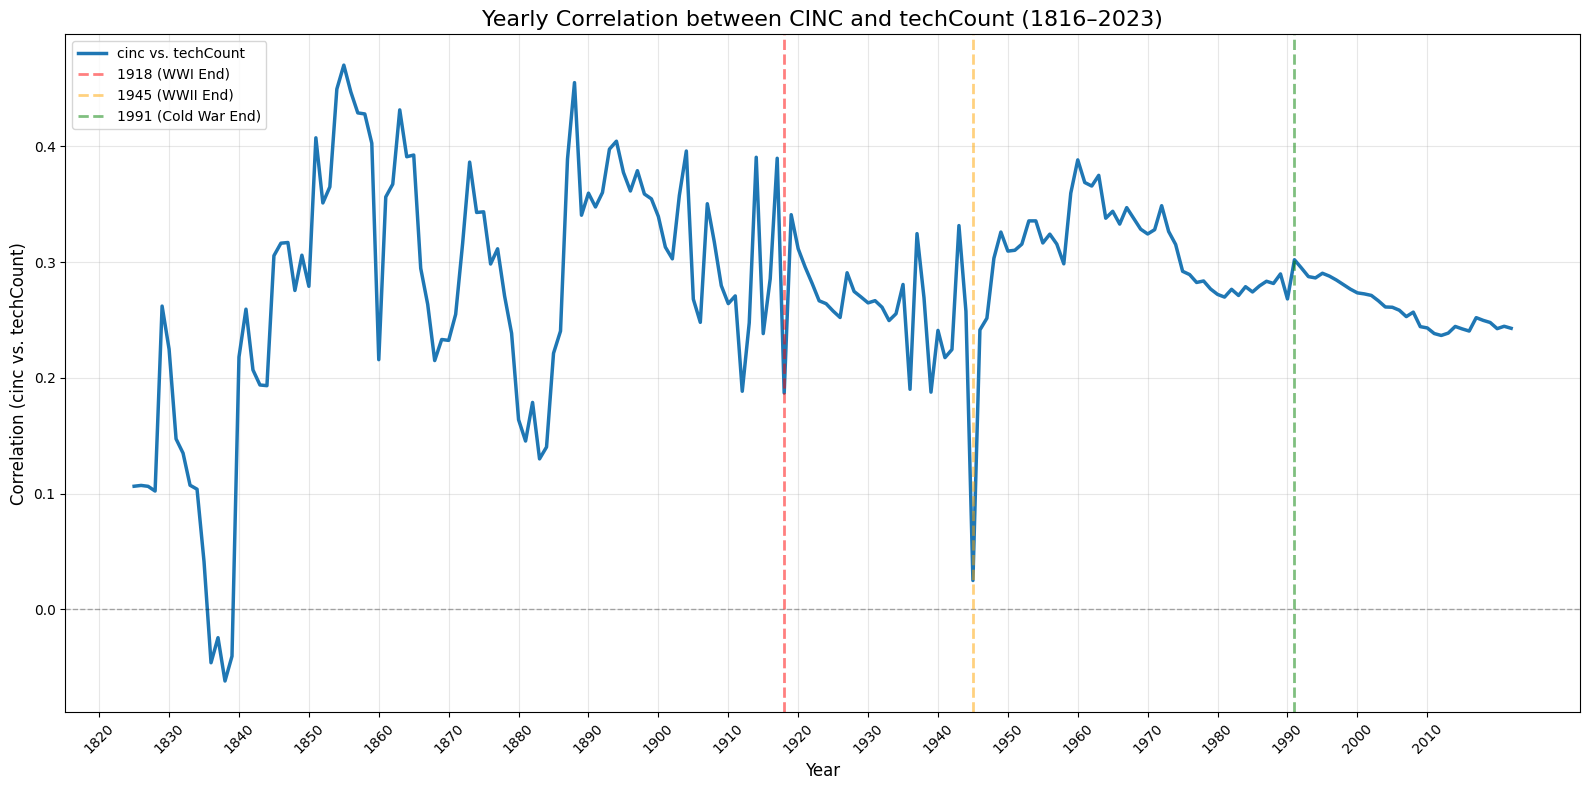

Pre‑WWI (1816–1918): r = 0.274
Post‑WWI (1919–2023): r = 0.282


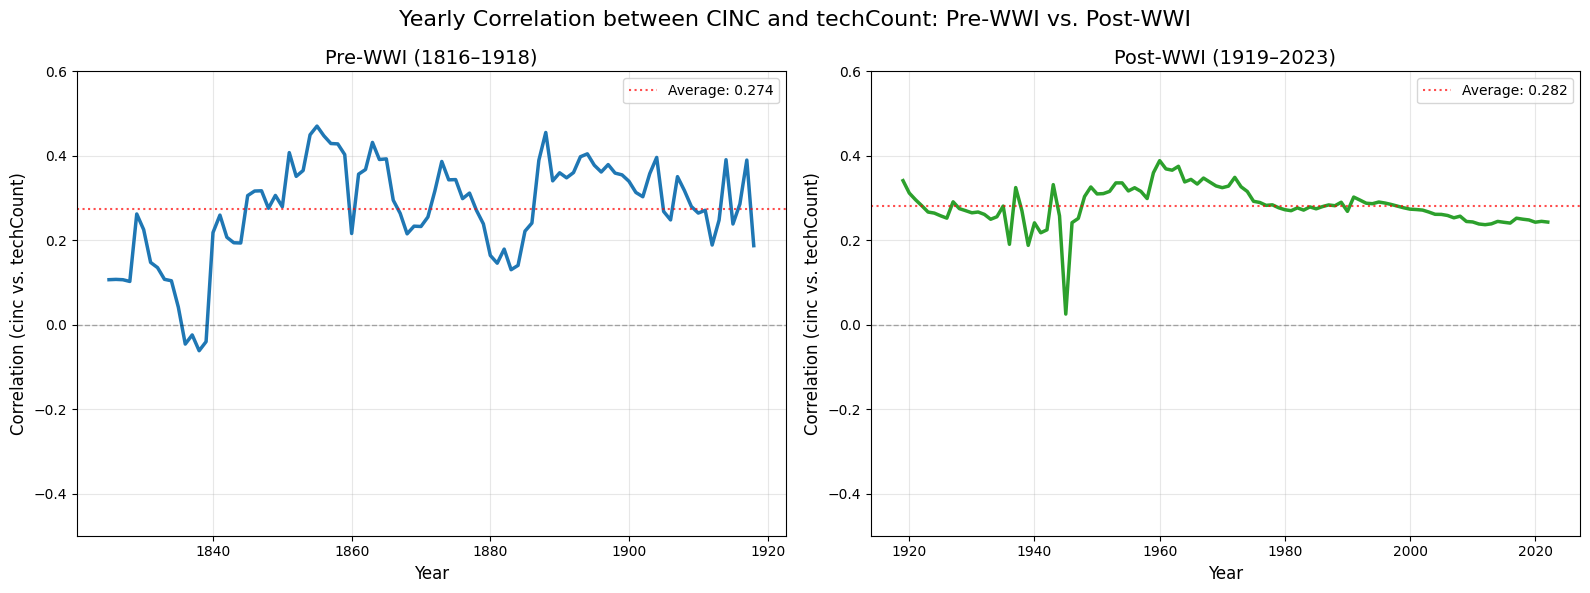

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================================
# 1. Compute yearly correlations (cinc vs. techCount)
# ============================================================================

years = sorted(analysisData['year'].unique())

year_list = []
corr_list = []

for year in years:
    year_data = analysisData[analysisData['year'] == year]
    
    # Skip years with too few observations
    if year_data.shape[0] < 10:
        continue
    
    # Compute correlation
    corr = year_data[['cinc', 'techCount']].corr().iloc[0, 1]
    
    year_list.append(year)
    corr_list.append(corr)

# Create DataFrame
yearly_corr = pd.DataFrame({
    'year': year_list,
    'correlation': corr_list
})

# ============================================================================
# 2. Line chart: Yearly correlation (cinc vs. techCount)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(yearly_corr['year'], yearly_corr['correlation'], 
        color='#1f77b4', linewidth=2.5, linestyle='-', label='cinc vs. techCount')

# Horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)

# Vertical lines for historical periods
ax.axvline(x=1918, color='red', linestyle='--', alpha=0.5, linewidth=2, label='1918 (WWI End)')
ax.axvline(x=1945, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='1945 (WWII End)')
ax.axvline(x=1991, color='green', linestyle='--', alpha=0.5, linewidth=2, label='1991 (Cold War End)')

# Decade ticks
tick_step = 10
tick_years = list(range(1820, 2020, tick_step))
ax.set_xticks(tick_years)
ax.set_xticklabels([str(y) for y in tick_years], rotation=45)

# Labels and title
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Correlation (cinc vs. techCount)', fontsize=12)
ax.set_title('Yearly Correlation between CINC and techCount (1816–2023)', fontsize=16)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# ============================================================================
# 3. Split the data at 1918
# ============================================================================

cutoff = 1918

pre_wwi = yearly_corr[yearly_corr['year'] <= cutoff]
post_wwi = yearly_corr[yearly_corr['year'] > cutoff]

# Compute average correlations
avg_pre = pre_wwi['correlation'].mean()
avg_post = post_wwi['correlation'].mean()

print(f"Pre‑WWI (1816–1918): r = {avg_pre:.3f}")
print(f"Post‑WWI (1919–2023): r = {avg_post:.3f}")

# ============================================================================
# 4. Side‑by‑side line charts
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----- Pre‑WWI plot -----
ax = axes[0]
ax.plot(pre_wwi['year'], pre_wwi['correlation'], 
        color='#1f77b4', linewidth=2.5, linestyle='-')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=avg_pre, color='red', linestyle=':', alpha=0.7, linewidth=1.5, label=f'Average: {avg_pre:.3f}')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Correlation (cinc vs. techCount)', fontsize=12)
ax.set_title(f'Pre‑WWI (1816–1918)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 0.6)

# ----- Post‑WWI plot -----
ax = axes[1]
ax.plot(post_wwi['year'], post_wwi['correlation'], 
        color='#2ca02c', linewidth=2.5, linestyle='-')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=avg_post, color='red', linestyle=':', alpha=0.7, linewidth=1.5, label=f'Average: {avg_post:.3f}')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Correlation (cinc vs. techCount)', fontsize=12)
ax.set_title(f'Post‑WWI (1919–2023)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 0.6)

plt.suptitle('Yearly Correlation between CINC and techCount: Pre‑WWI vs. Post‑WWI', fontsize=16)
plt.tight_layout()
plt.show()

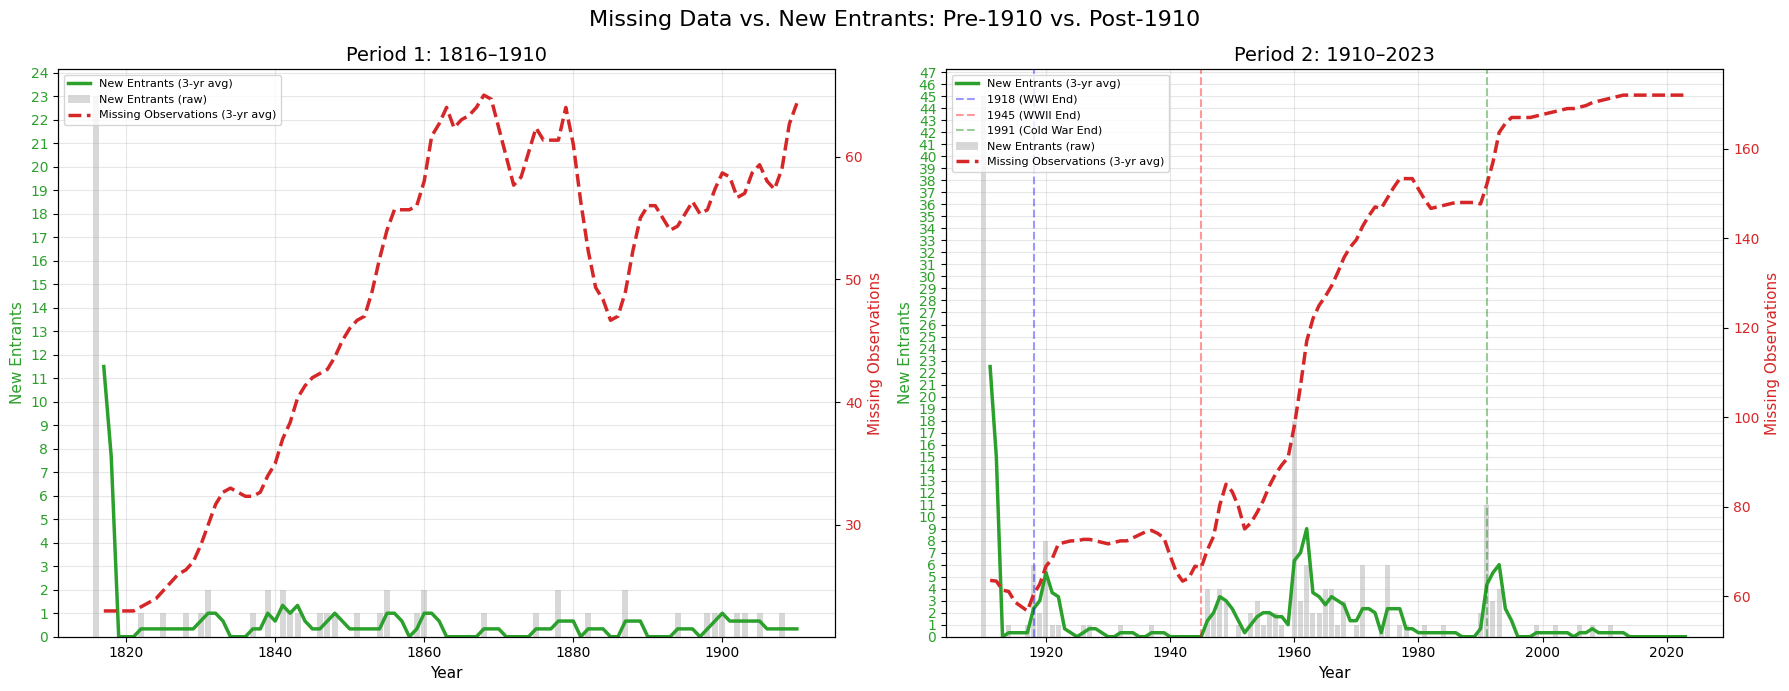


PERIOD: 1816–1910

Pearson correlation: -0.1845
P-value: 0.0734
  → Not statistically significant (p ≥ 0.05)

Lagged correlations:
  Lag 1: r = -0.1855, p = 0.0734
  Lag 2: r = -0.1953, p = 0.0607
  Lag 3: r = -0.2104, p = 0.0441

PERIOD: 1910–2023

Pearson correlation: -0.1223
P-value: 0.1950
  → Not statistically significant (p ≥ 0.05)

Lagged correlations:
  Lag 1: r = -0.1179, p = 0.2136
  Lag 2: r = -0.1119, p = 0.2402
  Lag 3: r = -0.1171, p = 0.2211

SUMMARY COMPARISON

Period 1 (1816–1910):
  r = -0.1845, p = 0.0734
  Average missing per year: 48.3
  Average new entrants per year: 0.64

Period 2 (1910–2023):
  r = -0.1223, p = 0.1950
  Average missing per year: 119.3
  Average new entrants per year: 1.58

Difference in correlation: 0.0622
Difference in average missing: 71.1

PERIOD: 1910–2023 (excluding [1910, 1911])

Pearson correlation: -0.0454
P-value: 0.6347
  → Not statistically significant (p ≥ 0.05)

Lagged correlations:
  Lag 1: r = -0.0298, p = 0.7559
  Lag 2: r = -0.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import pearsonr

# ============================================================================
# 1. Define periods
# ============================================================================

period1_start = 1816
period1_end = 1910
period2_start = 1910
period2_end = int(armsData['year'].max())

# ============================================================================
# 2. Function: Prepare data for a given period
# ============================================================================

def prepare_period_data(armsData, start_year, end_year):
    """Prepare missing data and new entrants for a given period."""
    
    # Filter armsData to the period
    armsData_period = armsData[(armsData['year'] >= start_year) & (armsData['year'] <= end_year)]
    
    # Count missing observations per year
    missing_by_year = armsData_period[armsData_period['use'].isnull()].groupby('year').size().reset_index()
    missing_by_year.columns = ['year', 'missing_count']
    
    # Count new entrants per year
    first_appearance = armsData_period.groupby('ccode')['year'].min().reset_index()
    first_appearance.columns = ['ccode', 'first_year']
    new_entrants = first_appearance.groupby('first_year').size().reset_index()
    new_entrants.columns = ['year', 'new_entrants']
    
    # Ensure all years are represented
    all_years = pd.DataFrame({'year': range(start_year, end_year + 1)})
    missing_by_year = pd.merge(all_years, missing_by_year, on='year', how='left').fillna(0)
    new_entrants = pd.merge(all_years, new_entrants, on='year', how='left').fillna(0)
    
    # Compute rolling averages
    window = 3
    missing_by_year['missing_rolling'] = missing_by_year['missing_count'].rolling(window=window, min_periods=2).mean()
    new_entrants['entrants_rolling'] = new_entrants['new_entrants'].rolling(window=window, min_periods=2).mean()
    
    return missing_by_year, new_entrants

# ============================================================================
# 3. Prepare data for both periods
# ============================================================================

missing1, entrants1 = prepare_period_data(armsData, period1_start, period1_end)
missing2, entrants2 = prepare_period_data(armsData, period2_start, period2_end)


# ============================================================================
# 4. Visualisation: Side-by-side plots
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ----- Period 1: 1816–1910 -----
ax = axes[0]

# Bar chart: New entrants (raw)
ax.bar(entrants1['year'], entrants1['new_entrants'], 
       color='gray', alpha=0.3, width=0.8, label='New Entrants (raw)')

# Line: New entrants (rolling average)
ax.plot(entrants1['year'], entrants1['entrants_rolling'], 
        color='#2ca02c', linewidth=2.5, linestyle='-', label='New Entrants (3‑yr avg)')

# Second axis: Missing data
ax2 = ax.twinx()
ax2.plot(missing1['year'], missing1['missing_rolling'], 
         color='#d62728', linewidth=2.5, linestyle='--', label='Missing Observations (3‑yr avg)')
ax2.set_ylabel('Missing Observations', color='#d62728', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Formatting
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('New Entrants', color='#2ca02c', fontsize=11)
ax.tick_params(axis='y', labelcolor='#2ca02c')
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_title(f'Period 1: {period1_start}–{period1_end}', fontsize=14)
ax.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# ----- Period 2: 1910–present -----
ax = axes[1]

# Bar chart: New entrants (raw)
ax.bar(entrants2['year'], entrants2['new_entrants'], 
       color='gray', alpha=0.3, width=0.8, label='New Entrants (raw)')

# Line: New entrants (rolling average)
ax.plot(entrants2['year'], entrants2['entrants_rolling'], 
        color='#2ca02c', linewidth=2.5, linestyle='-', label='New Entrants (3‑yr avg)')

# Second axis: Missing data
ax2 = ax.twinx()
ax2.plot(missing2['year'], missing2['missing_rolling'], 
         color='#d62728', linewidth=2.5, linestyle='--', label='Missing Observations (3‑yr avg)')
ax2.set_ylabel('Missing Observations', color='#d62728', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#d62728')

# Formatting
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('New Entrants', color='#2ca02c', fontsize=11)
ax.tick_params(axis='y', labelcolor='#2ca02c')
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# Add vertical lines for historical periods
ax.axvline(x=1918, color='blue', linestyle='--', alpha=0.4, label='1918 (WWI End)')
ax.axvline(x=1945, color='red', linestyle='--', alpha=0.4, label='1945 (WWII End)')
ax.axvline(x=1991, color='green', linestyle='--', alpha=0.4, label='1991 (Cold War End)')

ax.set_title(f'Period 2: {period2_start}–{period2_end}', fontsize=14)
ax.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Missing Data vs. New Entrants: Pre‑1910 vs. Post‑1910', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. Statistical analysis for each period
# ============================================================================

def analyze_period(missing_data, entrants_data, period_name):
    """Run correlation and lag analysis for a period."""
    
    print(f"\n{'='*60}")
    print(f"PERIOD: {period_name}")
    print('='*60)
    
    # Merge the two series
    merged = pd.merge(missing_data, entrants_data, on='year', how='inner')
    
    # Pearson correlation
    corr, p_value = pearsonr(merged['new_entrants'], merged['missing_count'])
    print(f"\nPearson correlation: {corr:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    # Interpret significance
    if p_value < 0.05:
        print("  → Statistically significant (p < 0.05)")
    else:
        print("  → Not statistically significant (p ≥ 0.05)")
    
    # Lagged correlations
    merged = merged.sort_values('year')
    merged['new_entrants_lag1'] = merged['new_entrants'].shift(1)
    merged['new_entrants_lag2'] = merged['new_entrants'].shift(2)
    merged['new_entrants_lag3'] = merged['new_entrants'].shift(3)
    
    print("\nLagged correlations:")
    for lag in [1, 2, 3]:
        lag_col = f'new_entrants_lag{lag}'
        temp = merged[['missing_count', lag_col]].dropna()
        corr_lag, p_lag = pearsonr(temp[lag_col], temp['missing_count'])
        print(f"  Lag {lag}: r = {corr_lag:.4f}, p = {p_lag:.4f}")

# Run analysis for both periods
analyze_period(missing1, entrants1, f"{period1_start}–{period1_end}")
analyze_period(missing2, entrants2, f"{period2_start}–{period2_end}")

# ============================================================================
# 6. Summary comparison
# ============================================================================

print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)

# Merge both periods for comparison
merged1 = pd.merge(missing1, entrants1, on='year', how='inner')
merged2 = pd.merge(missing2, entrants2, on='year', how='inner')

corr1, p1 = pearsonr(merged1['new_entrants'], merged1['missing_count'])
corr2, p2 = pearsonr(merged2['new_entrants'], merged2['missing_count'])

print(f"\nPeriod 1 ({period1_start}–{period1_end}):")
print(f"  r = {corr1:.4f}, p = {p1:.4f}")
print(f"  Average missing per year: {missing1['missing_count'].mean():.1f}")
print(f"  Average new entrants per year: {entrants1['new_entrants'].mean():.2f}")

print(f"\nPeriod 2 ({period2_start}–{period2_end}):")
print(f"  r = {corr2:.4f}, p = {p2:.4f}")
print(f"  Average missing per year: {missing2['missing_count'].mean():.1f}")
print(f"  Average new entrants per year: {entrants2['new_entrants'].mean():.2f}")

print(f"\nDifference in correlation: {corr2 - corr1:.4f}")
print(f"Difference in average missing: {missing2['missing_count'].mean() - missing1['missing_count'].mean():.1f}")

# Identify the spike year (likely 1910 or 1911, depending on your data)
spike_years = [1910, 1911]  # Adjust based on where the spike appears

# Filter out the spike years
missing2_filtered = missing2[~missing2['year'].isin(spike_years)]
entrants2_filtered = entrants2[~entrants2['year'].isin(spike_years)]

# Re-run the analysis for Period 2 without the spike
analyze_period(missing2_filtered, entrants2_filtered, f"1910–2023 (excluding {spike_years})")

# Identify the spike year (likely 1816 or 1817, depending on your data)
spike_years_period1 = [1816, 1817]  # Adjust based on where the spike appears

# Filter out the spike years
missing1_filtered = missing1[~missing1['year'].isin(spike_years_period1)]
entrants1_filtered = entrants1[~entrants1['year'].isin(spike_years_period1)]

# Re-run the analysis for Period 1 without the spike
analyze_period(missing1_filtered, entrants1_filtered, f"1816–1910 (excluding {spike_years_period1})")

CORE NATIONS (Based on Wallerstein's World-Systems Theory)

Core states are defined as those that were industrialised, had strong state
institutions, and were central to the world economy. This includes Western
Europe, North America, Japan, Australia, New Zealand, and historically
important states such as Israel and South Africa.

----------------------------------------------------------------------
Total core states: 26
----------------------------------------------------------------------
  • Austria-Hungary (300)
  • Belarus (370)
  • Bulgaria (355)
  • Canada (20)
  • Czechoslovakia (315)
  • Finland (375)
  • France (220)
  • German Federal Republic (260)
  • Germany (255)
  • Greece (350)
  • Hungary (310)
  • Iceland (395)
  • Italy (325)
  • Morocco (600)
  • Netherlands (210)
  • Poland (290)
  • Portugal (235)
  • Russia (365)
  • Spain (230)
  • Switzerland (225)
  • United Kingdom (200)
  • United States of America (2)
  • Unknown (330)
  • Unknown (340)
  • Unknown (410)


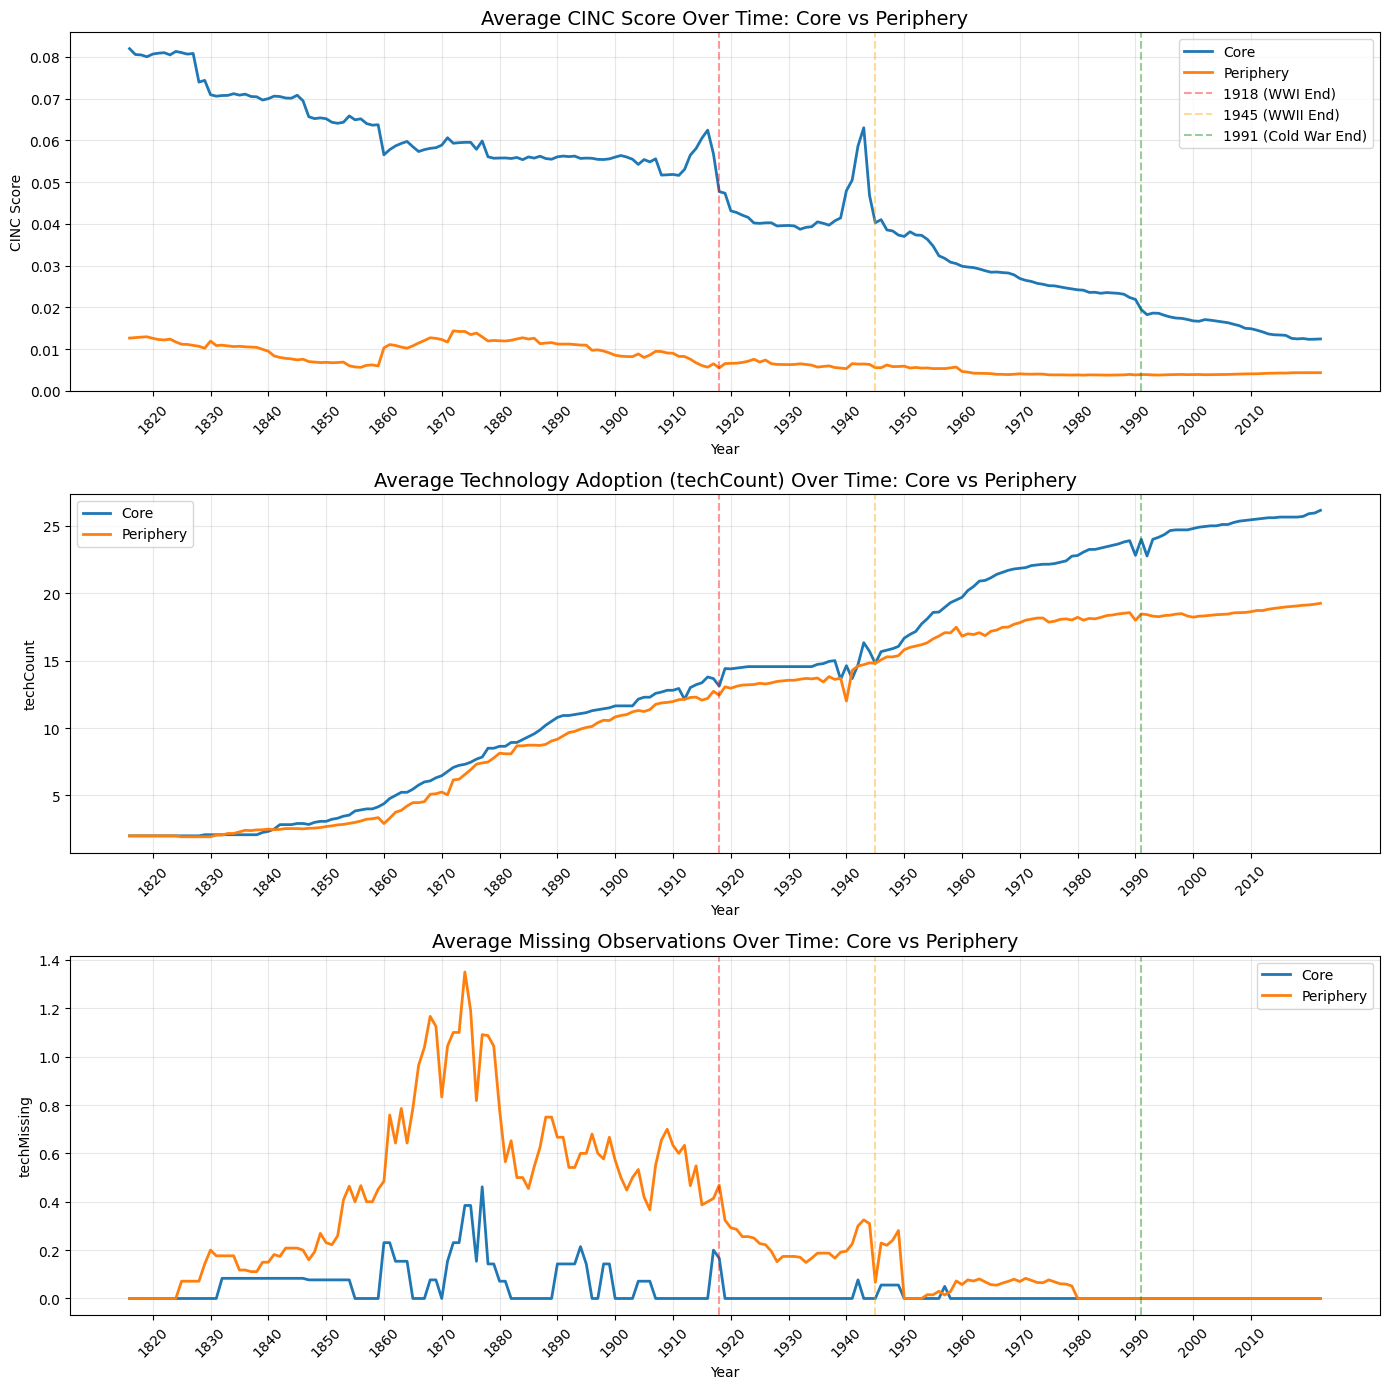


STATISTICAL COMPARISON: CORE vs PERIPHERY

Core states: 3339 country-years
Periphery states: 13782 country-years

--- CINC Score ---
  Core mean: 0.0417
  Periphery mean: 0.0053
  T-test: t = 57.6120, p = 0.0000

--- Technology Adoption (techCount) ---
  Core mean: 15.2
  Periphery mean: 15.7
  T-test: t = -3.4553, p = 0.0006

--- Missing Data (techMissing) ---
  Core mean: 0.0
  Periphery mean: 0.1
  T-test: t = -10.3155, p = 0.0000


KeyError: 'birth_year'

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import ttest_ind

# ============================================================================
# 1. Define core states (Wallerstein's core + additional major powers)
# ============================================================================

# COW country codes for core states
# This list includes: Western Europe, USA, Canada, Japan, Australia, New Zealand,
# and other historically core states (e.g., Israel, South Africa)
core_codes = [
    2,    # USA
    20,   # Canada
    200,  # UK
    210,  # Netherlands
    220,  # France
    225,  # Switzerland
    230,  # Spain
    235,  # Portugal
    255,  # Germany
    260,  # Austria
    290,  # Poland
    300,  # Austria-Hungary (historical)
    310,  # Hungary
    315,  # Czechoslovakia (historical)
    325,  # Italy
    330,  # Finland
    340,  # Denmark
    345,  # Sweden
    350,  # Norway
    355,  # Belgium
    365,  # Russia / USSR
    370,  # Belarus
    375,  # Georgia
    395,  # Russia (modern)
    410,  # Ukraine
    600,  # Japan
]

# ============================================================================
# 2. Load country names for printing
# ============================================================================

# Load country codes file
country_codes = pd.read_csv('../data/COW-country-codes.csv')
country_codes.columns = ['stateabb', 'ccode', 'statename']

# Create a lookup dictionary
core_names = []
for code in core_codes:
    match = country_codes[country_codes['ccode'] == code]
    if not match.empty:
        core_names.append(f"{match['statename'].iloc[0]} ({code})")
    else:
        core_names.append(f"Unknown ({code})")

# Sort alphabetically
core_names = sorted(core_names)

# ============================================================================
# 3. Print the list of core nations
# ============================================================================

print("="*70)
print("CORE NATIONS (Based on Wallerstein's World-Systems Theory)")
print("="*70)
print("\nCore states are defined as those that were industrialised, had strong state")
print("institutions, and were central to the world economy. This includes Western")
print("Europe, North America, Japan, Australia, New Zealand, and historically")
print("important states such as Israel and South Africa.")
print("\n" + "-"*70)
print(f"Total core states: {len(core_names)}")
print("-"*70)
for name in core_names:
    print(f"  • {name}")
print("-"*70)

# ============================================================================
# 4. Identify each state's "birth" year and core/periphery classification
# ============================================================================

first_appearance = armsData.groupby('ccode')['year'].min().reset_index()
first_appearance.columns = ['ccode', 'birth_year']
analysisData = pd.merge(analysisData, first_appearance, on='ccode', how='left')

analysisData['is_core'] = analysisData['ccode'].isin(core_codes)

# ============================================================================
# 5. Aggregate by year and core/periphery
# ============================================================================

yearly_core = analysisData[analysisData['is_core'] == True].groupby('year').agg({
    'cinc': 'mean',
    'techCount': 'mean',
    'techMissing': 'mean'
}).reset_index()
yearly_core['group'] = 'Core'

yearly_periphery = analysisData[analysisData['is_core'] == False].groupby('year').agg({
    'cinc': 'mean',
    'techCount': 'mean',
    'techMissing': 'mean'
}).reset_index()
yearly_periphery['group'] = 'Periphery'

yearly_combined = pd.concat([yearly_core, yearly_periphery], ignore_index=True)

# ============================================================================
# 6. Line charts
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# 6.1 CINC over time
ax = axes[0]
for group, data in yearly_combined.groupby('group'):
    ax.plot(data['year'], data['cinc'], linewidth=2, label=group)
ax.axvline(x=1918, color='red', linestyle='--', alpha=0.4, label='1918 (WWI End)')
ax.axvline(x=1945, color='orange', linestyle='--', alpha=0.4, label='1945 (WWII End)')
ax.axvline(x=1991, color='green', linestyle='--', alpha=0.4, label='1991 (Cold War End)')
ax.set_title('Average CINC Score Over Time: Core vs Periphery', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('CINC Score')
ax.legend()
ax.grid(True, alpha=0.3)

# 6.2 techCount over time
ax = axes[1]
for group, data in yearly_combined.groupby('group'):
    ax.plot(data['year'], data['techCount'], linewidth=2, label=group)
ax.axvline(x=1918, color='red', linestyle='--', alpha=0.4)
ax.axvline(x=1945, color='orange', linestyle='--', alpha=0.4)
ax.axvline(x=1991, color='green', linestyle='--', alpha=0.4)
ax.set_title('Average Technology Adoption (techCount) Over Time: Core vs Periphery', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('techCount')
ax.legend()
ax.grid(True, alpha=0.3)

# 6.3 Missing Data over time
ax = axes[2]
for group, data in yearly_combined.groupby('group'):
    ax.plot(data['year'], data['techMissing'], linewidth=2, label=group)
ax.axvline(x=1918, color='red', linestyle='--', alpha=0.4)
ax.axvline(x=1945, color='orange', linestyle='--', alpha=0.4)
ax.axvline(x=1991, color='green', linestyle='--', alpha=0.4)
ax.set_title('Average Missing Observations Over Time: Core vs Periphery', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('techMissing')
ax.legend()
ax.grid(True, alpha=0.3)

# Decade ticks for all axes
for ax in axes:
    tick_step = 10
    tick_years = list(range(1820, 2020, tick_step))
    ax.set_xticks(tick_years)
    ax.set_xticklabels([str(y) for y in tick_years], rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# 7. Statistical comparison
# ============================================================================

core_data = analysisData[analysisData['is_core'] == True]
periphery_data = analysisData[analysisData['is_core'] == False]

print("\n" + "="*60)
print("STATISTICAL COMPARISON: CORE vs PERIPHERY")
print("="*60)

print(f"\nCore states: {len(core_data)} country-years")
print(f"Periphery states: {len(periphery_data)} country-years")

print("\n--- CINC Score ---")
t_stat, p_val = ttest_ind(core_data['cinc'], periphery_data['cinc'])
print(f"  Core mean: {core_data['cinc'].mean():.4f}")
print(f"  Periphery mean: {periphery_data['cinc'].mean():.4f}")
print(f"  T-test: t = {t_stat:.4f}, p = {p_val:.4f}")

print("\n--- Technology Adoption (techCount) ---")
t_stat, p_val = ttest_ind(core_data['techCount'], periphery_data['techCount'])
print(f"  Core mean: {core_data['techCount'].mean():.1f}")
print(f"  Periphery mean: {periphery_data['techCount'].mean():.1f}")
print(f"  T-test: t = {t_stat:.4f}, p = {p_val:.4f}")

print("\n--- Missing Data (techMissing) ---")
t_stat, p_val = ttest_ind(core_data['techMissing'], periphery_data['techMissing'])
print(f"  Core mean: {core_data['techMissing'].mean():.1f}")
print(f"  Periphery mean: {periphery_data['techMissing'].mean():.1f}")
print(f"  T-test: t = {t_stat:.4f}, p = {p_val:.4f}")

# ============================================================================
# 8. Post-colonial comparison
# ============================================================================

analysisData['is_post_colonial'] = (analysisData['birth_year'] > 1945) & (analysisData['is_core'] == False)

yearly_postcol = analysisData[analysisData['is_post_colonial'] == True].groupby('year').agg({
    'cinc': 'mean',
    'techCount': 'mean',
    'techMissing': 'mean'
}).reset_index()
yearly_postcol['group'] = 'Post-Colonial'

yearly_other = analysisData[analysisData['is_post_colonial'] == False].groupby('year').agg({
    'cinc': 'mean',
    'techCount': 'mean',
    'techMissing': 'mean'
}).reset_index()
yearly_other['group'] = 'Other'

yearly_post_combined = pd.concat([yearly_postcol, yearly_other], ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, var, label in zip(axes, ['cinc', 'techCount', 'techMissing'], 
                          ['CINC Score', 'techCount', 'techMissing']):
    for group, data in yearly_post_combined.groupby('group'):
        ax.plot(data['year'], data[var], linewidth=2, label=group)
    ax.axvline(x=1945, color='red', linestyle='--', alpha=0.4, label='1945 (WWII End)')
    ax.set_title(f'Average {label} Over Time: Post-Colonial vs Other States', fontsize=14)
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
    tick_step = 10
    tick_years = list(range(1820, 2020, tick_step))
    ax.set_xticks(tick_years)
    ax.set_xticklabels([str(y) for y in tick_years], rotation=45)

plt.tight_layout()
plt.show()